## Load the data

In [3]:
import numpy as np

# Load training data
train_data = np.genfromtxt(
    "/content/loan_sanction_train.csv",
    delimiter=",",
    dtype=str,
    skip_header=1
)

# Load test_data
test_data = np.genfromtxt(
    "/content/loan_sanction_test.csv",
    delimiter=",",
    dtype=str,
    skip_header=1
)

## Inspect the data

In [4]:
print("Training data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

Training data shape: (614, 13)
Test data shape: (367, 12)


In [8]:
print(train_data[:5,:])

[['LP001002' 'Male' 'No' '0' 'Graduate' 'No' '5849' '0' '' '360' '1'
  'Urban' 'Y']
 ['LP001003' 'Male' 'Yes' '1' 'Graduate' 'No' '4583' '1508' '128' '360'
  '1' 'Rural' 'N']
 ['LP001005' 'Male' 'Yes' '0' 'Graduate' 'Yes' '3000' '0' '66' '360' '1'
  'Urban' 'Y']
 ['LP001006' 'Male' 'Yes' '0' 'Not Graduate' 'No' '2583' '2358' '120'
  '360' '1' 'Urban' 'Y']
 ['LP001008' 'Male' 'No' '0' 'Graduate' 'No' '6000' '0' '141' '360' '1'
  'Urban' 'Y']]


## Inspect the dataset

In [9]:
headers = np.genfromtxt(
    "/content/loan_sanction_train.csv",
    delimiter=",",
    dtype=str,
    max_rows=1
)
print("Headers \n", headers)

Headers 
 ['Loan_ID' 'Gender' 'Married' 'Dependents' 'Education' 'Self_Employed'
 'ApplicantIncome' 'CoapplicantIncome' 'LoanAmount' 'Loan_Amount_Term'
 'Credit_History' 'Property_Area' 'Loan_Status']


## Find missing values

In [12]:
# Count missing values in each column

missing_counts = np.sum(train_data == "", axis=0)
for header, count in zip(headers, missing_counts):
    print(f"{header:20}: {count}")

Loan_ID             : 0
Gender              : 13
Married             : 3
Dependents          : 15
Education           : 0
Self_Employed       : 32
ApplicantIncome     : 0
CoapplicantIncome   : 0
LoanAmount          : 22
Loan_Amount_Term    : 14
Credit_History      : 50
Property_Area       : 0
Loan_Status         : 0


In [13]:
columns_to_check = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in columns_to_check:
    idx = np.where(headers == column)[0][0]
    print(f"\n{column}")
    print(np.unique(train_data[:, idx]))


Gender
['' 'Female' 'Male']

Married
['' 'No' 'Yes']

Dependents
['' '0' '1' '2' '3+']

Self_Employed
['' 'No' 'Yes']

LoanAmount
['' '100' '101' '102' '103' '104' '105' '106' '107' '108' '109' '110'
 '111' '112' '113' '114' '115' '116' '117' '118' '119' '120' '121' '122'
 '123' '124' '125' '126' '127' '128' '129' '130' '131' '132' '133' '134'
 '135' '136' '137' '138' '139' '140' '141' '142' '143' '144' '145' '146'
 '148' '149' '150' '151' '152' '153' '154' '155' '156' '157' '158' '159'
 '160' '161' '162' '164' '165' '166' '167' '168' '17' '170' '172' '173'
 '175' '176' '178' '180' '181' '182' '184' '185' '186' '187' '188' '190'
 '191' '192' '194' '196' '200' '201' '205' '207' '208' '209' '210' '211'
 '214' '216' '218' '225' '228' '230' '234' '236' '239' '240' '242' '243'
 '244' '246' '25' '250' '253' '255' '258' '259' '26' '260' '265' '267'
 '275' '279' '280' '286' '290' '292' '296' '30' '300' '304' '308' '311'
 '312' '315' '320' '324' '330' '349' '35' '350' '36' '360' '370' '376'
 '

In [14]:
def fill_mode(data, column_index):
    # Get all non-missing values
    values = data[:, column_index]
    values = values[values != ""]

    # Find unique values and their counts
    unique, counts = np.unique(values, return_counts=True)

    # Most frequent value
    mode = unique[np.argmax(counts)]

    # Replace missing values
    data[data[:, column_index] == "", column_index] = mode

    return mode

In [15]:
categorical_columns = [
    "Gender",
    "Married",
    "Dependents",
    "Self_Employed",
    "Loan_Amount_Term",
    "Credit_History"
]

for column in categorical_columns:
    idx = np.where(headers == column)[0][0]
    mode = fill_mode(train_data, idx)
    print(f"{column:20} -> {mode}")

Gender               -> Male
Married              -> Yes
Dependents           -> 0
Self_Employed        -> No
Loan_Amount_Term     -> 360
Credit_History       -> 1


In [16]:
missing_counts = np.sum(train_data == "", axis=0)

for header, count in zip(headers, missing_counts):
    print(f"{header:20}: {count}")

Loan_ID             : 0
Gender              : 0
Married             : 0
Dependents          : 0
Education           : 0
Self_Employed       : 0
ApplicantIncome     : 0
CoapplicantIncome   : 0
LoanAmount          : 22
Loan_Amount_Term    : 0
Credit_History      : 0
Property_Area       : 0
Loan_Status         : 0


In [17]:
def fill_median(data, column_index):
    # Extract non-missing values
    values = data[:, column_index]
    values = values[values != ""].astype(float)

    # Compute median
    median = np.median(values)

    # Replace missing values
    data[data[:, column_index] == "", column_index] = str(median)

    return median

In [18]:
loan_idx = np.where(headers == "LoanAmount")[0][0]

median = fill_median(train_data, loan_idx)

print("Median Loan Amount:", median)

Median Loan Amount: 128.0


In [19]:
missing_counts = np.sum(train_data == "", axis=0)

for header, count in zip(headers, missing_counts):
    print(f"{header:20}: {count}")

Loan_ID             : 0
Gender              : 0
Married             : 0
Dependents          : 0
Education           : 0
Self_Employed       : 0
ApplicantIncome     : 0
CoapplicantIncome   : 0
LoanAmount          : 0
Loan_Amount_Term    : 0
Credit_History      : 0
Property_Area       : 0
Loan_Status         : 0


In [20]:
def encode_binary(data, column_index, mapping):
    column = data[:, column_index]

    for old_value, new_value in mapping.items():
        column[column == old_value] = str(new_value)

    data[:, column_index] = column

In [21]:
binary_mappings = {
    "Gender": {"Male": 1, "Female": 0},
    "Married": {"Yes": 1, "No": 0},
    "Education": {"Graduate": 1, "Not Graduate": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
    "Loan_Status": {"Y": 1, "N": 0}
}

for column, mapping in binary_mappings.items():
    idx = np.where(headers == column)[0][0]
    encode_binary(train_data, idx, mapping)

In [22]:
print(train_data[:5])

[['LP001002' '1' '0' '0' '1' '0' '5849' '0' '128.0' '360' '1' 'Urban' '1']
 ['LP001003' '1' '1' '1' '1' '0' '4583' '1508' '128' '360' '1' 'Rural'
  '0']
 ['LP001005' '1' '1' '0' '1' '1' '3000' '0' '66' '360' '1' 'Urban' '1']
 ['LP001006' '1' '1' '0' '0' '0' '2583' '2358' '120' '360' '1' 'Urban'
  '1']
 ['LP001008' '1' '0' '0' '1' '0' '6000' '0' '141' '360' '1' 'Urban' '1']]


## Delete Load_id column

In [23]:
loan_id_idx = np.where(headers == "Loan_ID")[0][0]

train_data = np.delete(train_data, loan_id_idx, axis=1)

# also remove from headers
headers = np.delete(headers, loan_id_idx)

In [24]:
print("Headers: ", headers)

Headers:  ['Gender' 'Married' 'Dependents' 'Education' 'Self_Employed'
 'ApplicantIncome' 'CoapplicantIncome' 'LoanAmount' 'Loan_Amount_Term'
 'Credit_History' 'Property_Area' 'Loan_Status']


## Encode Dependents

In [25]:
dep_idx = np.where(headers == "Dependents")[0][0]

train_data[:, dep_idx] = np.char.replace(train_data[:, dep_idx], "3+", "3")

train_data[:, dep_idx] = train_data[:, dep_idx].astype(int).astype(str)

## Encode Property_Area

In [28]:
prop_idx = np.where(headers == "Property_Area")[0][0]

mapping = {
    "Rural": 0,
    "Semiurban": 1,
    "Urban": 2
}

for k, v in mapping.items():
    train_data[:, prop_idx][train_data[:, prop_idx] == k] = str(v)

In [30]:
train_data[:, prop_idx][:10]

array(['2', '0', '2', '2', '2', '2', '2', '1', '2', '1'], dtype='<U12')

In [31]:
train_data = train_data.astype(float)

## Split features and target

In [37]:
target_idx = np.where(headers == "Loan_Status")[0][0]

X = train_data[:, :target_idx] if target_idx == train_data.shape[1] - 1 else np.delete(train_data, target_idx, axis=1)
y = train_data[:, target_idx].astype(float)

In [38]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("First 5 y values:", y[:5])

X shape: (614, 11)
y shape: (614,)
First 5 y values: [1. 0. 1. 1. 1.]


## Shuiffle the data

In [40]:
np.random.seed(42)

indices = np.arange(X.shape[0])
np.random.shuffle(indices)

X = X[indices]
y = y[indices]

## Split the data

In [41]:
split_ratio = 0.8
split_index = int(X.shape[0] * split_ratio)

print("Split index: ", split_index)

Split index:  491


In [42]:
X_train = X[:split_index]
X_test = X[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

In [43]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (491, 11)
X_test : (123, 11)
y_train: (491,)
y_test : (123,)


In [45]:
X_train[:5]

array([[1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 9.083e+03,
        0.000e+00, 2.280e+02, 3.600e+02, 1.000e+00, 1.000e+00],
       [1.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 4.310e+03,
        0.000e+00, 1.300e+02, 3.600e+02, 1.000e+00, 1.000e+00],
       [1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 4.167e+03,
        1.447e+03, 1.580e+02, 3.600e+02, 1.000e+00, 0.000e+00],
       [0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.900e+03,
        0.000e+00, 7.100e+01, 3.600e+02, 1.000e+00, 0.000e+00],
       [1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 2.718e+03,
        0.000e+00, 7.000e+01, 3.600e+02, 1.000e+00, 1.000e+00]])

In [46]:
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

print("Mean shape:", mean.shape)
print("Std shape:", std.shape)

Mean shape: (11,)
Std shape: (11,)


In [47]:
std[std == 0] = 1

In [48]:
X_train_scaled = (X_train - mean) / std

In [49]:
X_test_scaled = (X_test - mean) / std

In [51]:
print("Before scaling (first row):")
print(X_train[0])

print("\nAfter scaling (first row):")
print(X_train_scaled[0])

Before scaling (first row):
[1.000e+00 1.000e+00 0.000e+00 1.000e+00 0.000e+00 9.083e+03 0.000e+00
 2.280e+02 3.600e+02 1.000e+00 1.000e+00]

After scaling (first row):
[ 0.49936346  0.7441757  -0.71464596  0.51839546 -0.38714713  0.59713564
 -0.53982266  1.0324719   0.25766268  0.41453312 -0.02862507]


In [54]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

## Initialize parameters

In [53]:
n_features = X_train_scaled.shape[1]

w = np.zeros(n_features)
b = 0

In [55]:
def compute_loss(y, y_pred):
    m = len(y)
    eps = 1e-15 # avoid log(0)
    y_pred = np.clip(y_pred, eps, 1-eps)

    loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return loss

In [64]:
learning_rate = 0.01
epochs = 1000
m = X_train_scaled.shape[0]
loss_history = []

for i in range(epochs):
    # Forward pass
    z = np.dot(X_train_scaled, w) + b
    y_pred = sigmoid(z)

    # loss
    loss = compute_loss(y_train, y_pred)
    loss_history.append(loss)

    # Gradients
    dw = (1/m) * np.dot(X_train_scaled.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)

    # Update parameters
    w -= learning_rate * dw
    b -= learning_rate * db

    # Print progress
    if i % 100 == 0:
        print(f"Epoch {i}, loss: {loss:.4f}")

Epoch 0, loss: 0.4787
Epoch 100, loss: 0.4771
Epoch 200, loss: 0.4759
Epoch 300, loss: 0.4751
Epoch 400, loss: 0.4744
Epoch 500, loss: 0.4739
Epoch 600, loss: 0.4735
Epoch 700, loss: 0.4732
Epoch 800, loss: 0.4729
Epoch 900, loss: 0.4727


In [57]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(np.dot(X, w) + b)
    return (probs >= threshold).astype(int)

In [58]:
y_pred_test = predict(X_test_scaled, w, b)

accuracy = np.mean(y_pred_test == y_test)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.8211382113821138


In [59]:
TN = np.sum((y_test == 0) & (y_pred_test == 0))
FP = np.sum((y_test == 0) & (y_pred_test == 1))
FN = np.sum((y_test == 1) & (y_pred_test == 0))
TP = np.sum((y_test == 1) & (y_pred_test == 1))

print("Confusion Matrix")
print([[TN, FP],
       [FN, TP]])

Confusion Matrix
[[np.int64(16), np.int64(21)], [np.int64(1), np.int64(85)]]


In [60]:
precision = TP / (TP + FP)
print("Precision:", precision)

Precision: 0.8018867924528302


In [61]:
recall = TP / (TP + FN)
print("Recall:", recall)

Recall: 0.9883720930232558


In [63]:
f1 = 2 * precision * recall / (precision + recall)
print("F1 Score:", f1)

F1 Score: 0.8854166666666666


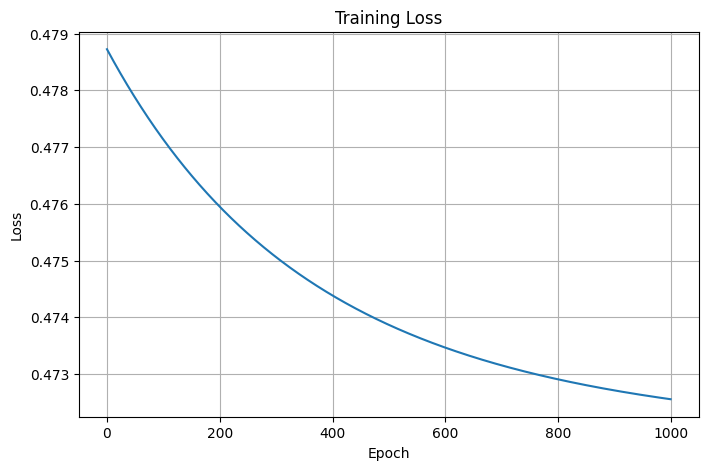

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [66]:
feature_names = headers[:-1]  # Loan_Status is the target

for name, weight in zip(feature_names, w):
    print(f"{name:20} {weight:.4f}")

Gender               0.0111
Married              0.1650
Dependents           -0.0603
Education            0.1887
Self_Employed        -0.0332
ApplicantIncome      0.0214
CoapplicantIncome    -0.1974
LoanAmount           -0.1259
Loan_Amount_Term     -0.0594
Credit_History       1.2071
Property_Area        0.0230


## Scikit implementation

In [67]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = np.mean(y_pred == y_test)

print("Sklearn Accuracy:", accuracy)

Sklearn Accuracy: 0.8211382113821138


In [68]:
print("Your weights")
print(w)

print("\nSklearn weights")
print(model.coef_[0])

print("\nYour bias")
print(b)

print("Sklearn bias")
print(model.intercept_[0])

Your weights
[ 0.0110689   0.16500978 -0.06034245  0.18869302 -0.03319612  0.02142525
 -0.19736975 -0.1259453  -0.0594392   1.2071243   0.02300521]

Sklearn weights
[-0.00154656  0.18819658 -0.05809591  0.20443262 -0.03755432  0.04388973
 -0.19994022 -0.15690033 -0.06369824  1.29228564  0.01694072]

Your bias
0.7916734327125763
Sklearn bias
0.7952620841540419
